# Casualty Statistics, 2010-2024

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = "data/dft-road-casualty-statistics-casualty-1979-latest-published-year.csv"
df = pd.read_csv(path)

df = df.loc[(df["collision_year"] >= 2014) & (df["collision_year"] <= 2024)].copy()
df["is_fatal"] = pd.to_numeric(df["casualty_severity"], errors="coerce").eq(1).astype(int) # STATS19 form, 1 = fatal

yearly = (
    df.groupby("collision_year")
      .agg(
          incidents=("collision_ref_no", "nunique"),
          deaths=("is_fatal", "sum"),
      )
      .reset_index()
      .sort_values("collision_year")
)

C:\Users\vadym\AppData\Local\Temp\ipykernel_22204\1068025822.py:5: DtypeWarning: Columns (0: lsoa_of_casualty) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [8]:
yearly["incidents_normalized"] = yearly["incidents"]
yearly["deaths_normalized"] = yearly["deaths"]
yearly["deaths_per_incident"] = yearly["deaths"] / yearly["incidents"]

yearly

,collision_year,incidents,deaths,incidents_normalized,deaths_normalized,deaths_per_incident
0,2014,146322,1775,146322,1775,0.012131
1,2015,140056,1730,140056,1730,0.012352
2,2016,136621,1792,136621,1792,0.013117
3,2017,129982,1793,129982,1793,0.013794
4,2018,122635,1784,122635,1784,0.014547
5,2019,117536,1752,117536,1752,0.014906
6,2020,91199,1460,91199,1460,0.016009
7,2021,101087,1558,101087,1558,0.015412
8,2022,106004,1711,106004,1711,0.016141
9,2023,104258,1624,104258,1624,0.015577


In [9]:
vehicle_path = "data/df_VEH0120_GB.csv"
vehicles = pd.read_csv(vehicle_path, encoding="latin1")

vehicles = vehicles.loc[vehicles["LicenceStatus"].eq("Licensed")].copy()

vehicle_yearly = []
for year in range(2014, 2025):
    year_columns = [f"{year} Q1", f"{year} Q2", f"{year} Q3", f"{year} Q4"]
    year_columns = [column for column in year_columns if column in vehicles.columns]

    if not year_columns:
        continue

    vehicle_total = (
        vehicles[year_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .sum()
        .sum()
    )

    vehicle_yearly.append({"collision_year": year, "vehicles": vehicle_total})

vehicle_yearly = pd.DataFrame(vehicle_yearly)

yearly = yearly.merge(vehicle_yearly, on="collision_year", how="left")
yearly["incidents_per_100k_vehicles"] = yearly["incidents"] / yearly["vehicles"] * 100000
yearly["deaths_per_100k_vehicles"] = yearly["deaths"] / yearly["vehicles"] * 100000

yearly

,collision_year,incidents,deaths,incidents_normalized,deaths_normalized,deaths_per_incident,vehicles,incidents_per_100k_vehicles,deaths_per_100k_vehicles
0,2014,146322,1775,146322,1775,0.012131,142434402,102.729395,1.246188
1,2015,140056,1730,140056,1730,0.012352,144308554,97.053152,1.198820
2,2016,136621,1792,136621,1792,0.013117,147911353,92.366811,1.211536
3,2017,129982,1793,129982,1793,0.013794,151055171,86.049355,1.186984
4,2018,122635,1784,122635,1784,0.014547,152641439,80.341879,1.168752
5,2019,117536,1752,117536,1752,0.014906,154668034,75.992432,1.132749
6,2020,91199,1460,91199,1460,0.016009,154107128,59.178963,0.947393
7,2021,101087,1558,101087,1558,0.015412,156126391,64.746901,0.997909
8,2022,106004,1711,106004,1711,0.016141,157519965,67.295596,1.086212
9,2023,104258,1624,104258,1624,0.015577,159429466,65.394436,1.018632


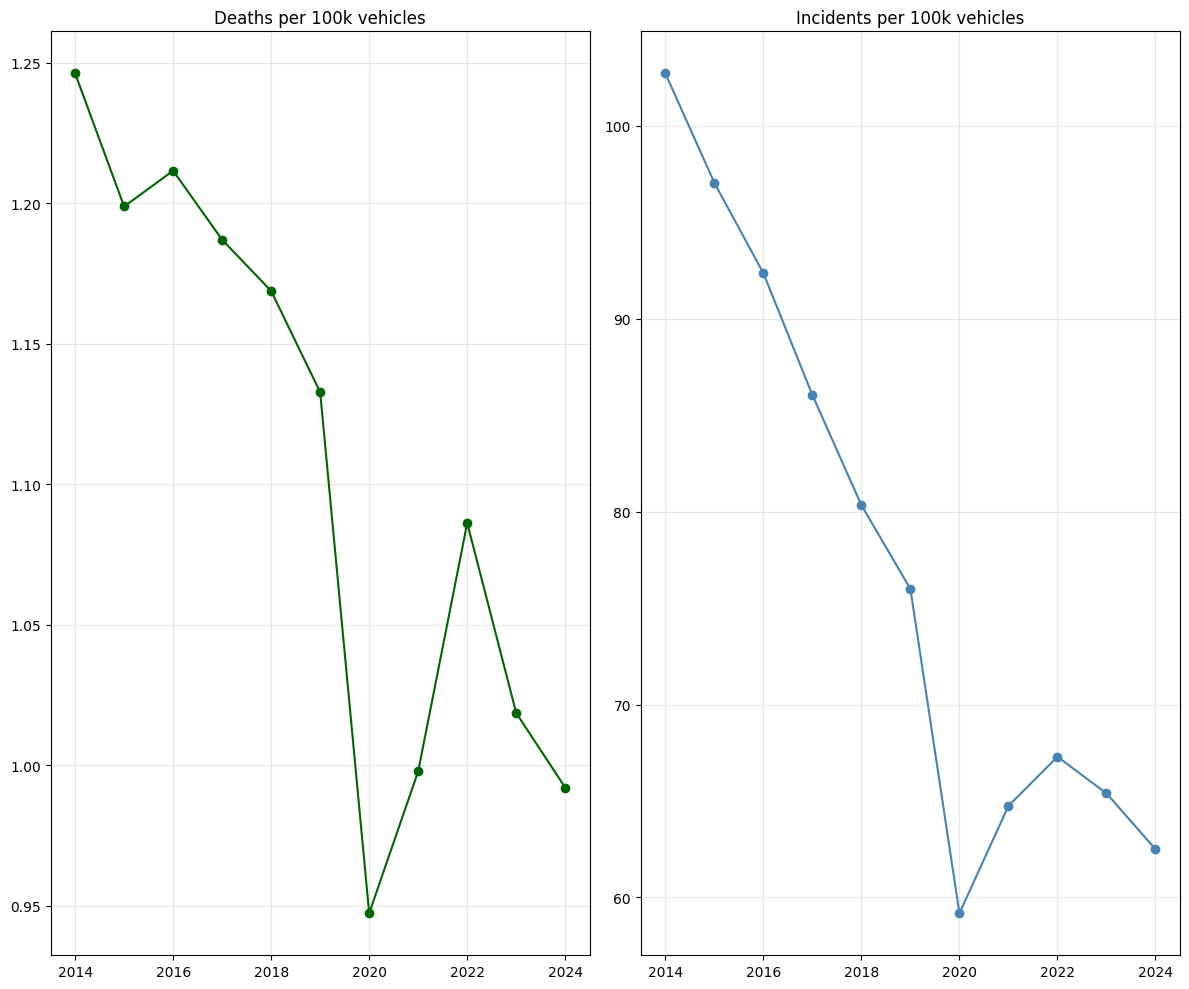

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))

ax1.plot(yearly["collision_year"], yearly["deaths_per_100k_vehicles"], 
         marker="o", color="darkgreen")
ax1.set_title("Deaths per 100k vehicles")
ax1.grid(alpha=0.3)

ax2.plot(yearly["collision_year"], yearly["incidents_per_100k_vehicles"], 
         marker="o", color="steelblue")
ax2.set_title("Incidents per 100k vehicles")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

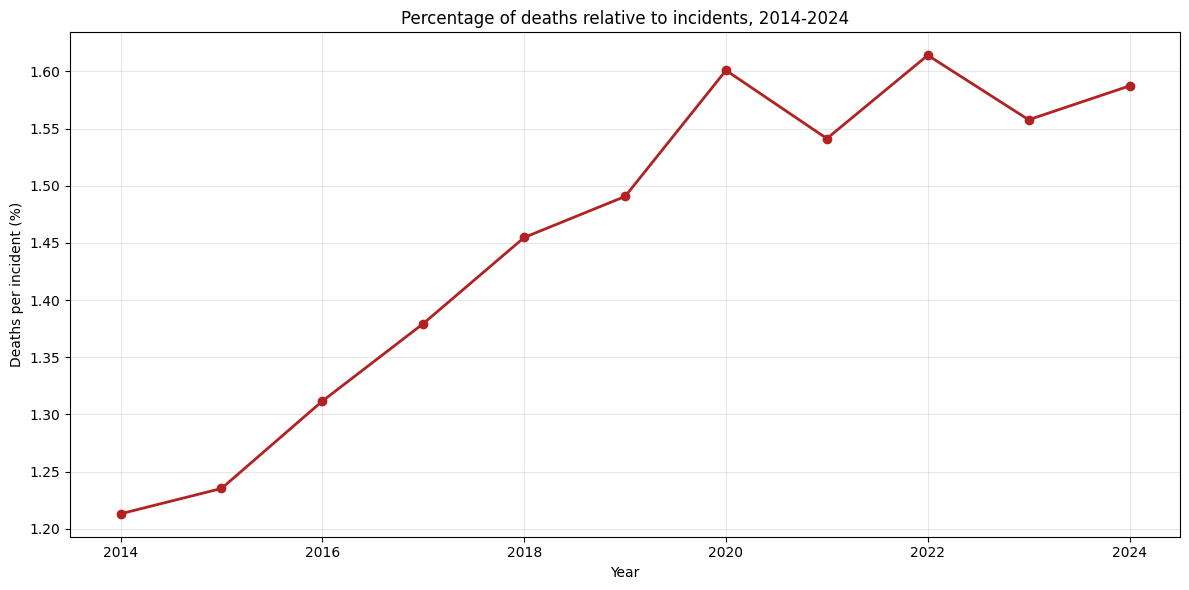

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(
    yearly["collision_year"],
    yearly["deaths_per_incident"] * 100,
    marker="o",
    color="firebrick",
    linewidth=2,
)
plt.title("Percentage of deaths relative to incidents, 2014-2024")
plt.xlabel("Year")
plt.ylabel("Deaths per incident (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()